In [1]:
!pip install pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 617.7/617.7 kB 10.7 MB/s eta 0:00:00


In [2]:
import pyreadstat
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from collections import Counter
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt


2025-06-13 00:29:58.330776: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749774598.516580      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749774598.575597      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# EDA

In [3]:
df_ch = pyreadstat.read_sav('/kaggle/input/malnutrition/ch.sav')[0]
# data = pd.read_spss('/kaggle/input/malnutrition/ch.sav')

# Renaming the columns
df1 = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = df1.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Remove rows with coded entries in each column
coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

df2 = df1.copy()
df2.dropna(inplace=True)

df2 = df2[~df2['child_age'].isin(coded_child_age)]
df2 = df2[~df2['underweight'].isin(coded_underweight)]
df2 = df2[~df2['stunting'].isin(coded_stunting)]
df2 = df2[~df2['wasting'].isin(coded_wasting)] 
df2 = df2[~df2['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df2 = df2[~df2['fever_last_2_weeks'].isin(coded_fever)]
df2 = df2[~df2['health_insurance'].isin(coded_insurance)]
df2 = df2[~df2['ever_breastfed'].isin(coded_breastfed)]

# Convert to Binary Response Variables

df2['underweight'] = [2 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [2 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [2 if -2 <= x < 2 else 1 for x in df2['wasting']]
df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df2 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)

# Change binary features from 1/2 to 1/0
df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']] = df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']].replace({1: 1, 2: 0})
df2.head(10)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,province,wealth_index,malnurished
0,1.0,7.8,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
2,2.0,11.1,1.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
3,1.0,9.3,1.0,1.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,0
5,0.0,6.9,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
6,1.0,10.5,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,0
7,1.0,10.4,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,0
10,1.0,8.8,1.0,0.0,0.0,0.0,1.0,2.0,0.0,1.0,1.0,1
13,1.0,9.7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1
15,1.0,10.3,1.0,0.0,0.0,0.0,1.0,5.0,0.0,1.0,1.0,1
16,1.0,7.7,1.0,0.0,0.0,0.0,0.0,2.0,0.0,1.0,1.0,1


In [4]:
#Scaling child weight
scaler = StandardScaler()
df2['child_weight'] = scaler.fit_transform(df2[['child_weight']])

In [5]:
# Label and one-hot-encoding for Ordinal/nominal features
le = LabelEncoder()
df2['mother_education'] = le.fit_transform(df2['mother_education'])
df2['wealth_index'] = le.fit_transform(df2['wealth_index'])
df2 = pd.get_dummies(df2, columns = ['province'])
df = df2.astype(int)
df.head()

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_1.0,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,0,1,0,0,0,1,2,0,0,1,1,0,0,0,0,0,0
2,2,0,1,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0
3,1,0,1,1,1,0,0,1,0,0,0,1,0,0,0,0,0,0
5,0,-1,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
6,1,0,1,0,0,0,1,2,0,0,0,1,0,0,0,0,0,0


# Artificial Neural Network

In [6]:
from kerastuner.tuners import RandomSearch
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import Recall
from kerastuner.tuners import RandomSearch
from tensorflow.keras.callbacks import EarlyStopping

/tmp/ipykernel_19/3109826212.py:1: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch


In [7]:
X = df.drop(columns=['malnurished'])
y = df['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

In [8]:
model = Sequential()
model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['recall'])

# early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,  
    epochs=100,            
    batch_size=16,
    # callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1749774613.532982      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1749774613.533669      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/100


I0000 00:00:1749774616.378550      66 service.cc:148] XLA service 0x7c54a8003ba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749774616.379081      66 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1749774616.379101      66 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1749774616.638667      66 cuda_dnn.cc:529] Loaded cuDNN version 90300


 77/144 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7179 - recall: 0.3278

I0000 00:00:1749774617.698236      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


144/144 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.7084 - recall: 0.2573 - val_loss: 0.6743 - val_recall: 0.1149
Epoch 2/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6772 - recall: 0.1860 - val_loss: 0.6645 - val_recall: 0.2759
Epoch 3/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6619 - recall: 0.2869 - val_loss: 0.6531 - val_recall: 0.4368
Epoch 4/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6467 - recall: 0.4007 - val_loss: 0.6480 - val_recall: 0.6015
Epoch 5/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6505 - recall: 0.5582 - val_loss: 0.6394 - val_recall: 0.5709
Epoch 6/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6282 - recall: 0.5428 - val_loss: 0.6365 - val_recall: 0.5862
Epoch 7/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6284 - recall: 0.6031 - val_loss: 0.6375 - val_recall: 0.4521
Epoch 8/100
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6240 - recall: 0.5434 - val_loss: 0.6330 - val_recall: 0.4713
Epoch 9/100

In [9]:
def build_model(hp):
    model = Sequential()
    model.add(Dense(
        units=hp.Int('units_input', min_value=16, max_value=128, step=16),
        activation='relu',
        input_shape=(X_train.shape[1],)
    ))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.5, step=0.1)))
    model.add(Dense(
        units=hp.Int('units_hidden', min_value=8, max_value=64, step=8),
        activation='relu'
    ))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('lr', [1e-1, 1e-2, 1e-3, 1e-4])),
        loss=BinaryCrossentropy(),
        metrics=[Recall()]
    )
    return model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


tuner = RandomSearch(
    build_model,
    objective='val_recall',
    max_trials=10,
    executions_per_trial=1,
    directory='tuner_dir',
    project_name='binary_class_tuning'
)

tuner.search(X_train, y_train, epochs=50, validation_split=0.2, callbacks=[early_stop])
best_model = tuner.get_best_models(num_models=1)[0]

Trial 10 Complete [00h 00m 12s]
val_recall: 0.5747126340866089

Best val_recall So Far: 0.9348658919334412
Total elapsed time: 00h 01m 59s


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [10]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(f"Input layer units: {best_hps.get('units_input')}")
print(f"Hidden layer units: {best_hps.get('units_hidden')}")
print(f"Dropout rate: {best_hps.get('dropout')}")
print(f"Learning rate: {best_hps.get('lr')}")


Best hyperparameters:
Input layer units: 64
Hidden layer units: 16
Dropout rate: 0.1
Learning rate: 0.1


In [11]:
best_model = build_model(best_hps)
best_model.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[early_stop])


Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.8488 - recall_1: 0.3508 - val_loss: 0.6581 - val_recall_1: 0.5747
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6499 - recall_1: 0.4575 - val_loss: 0.6843 - val_recall_1: 0.0038
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6736 - recall_1: 0.3465 - val_loss: 0.6508 - val_recall_1: 0.4943
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6540 - recall_1: 0.4506 - val_loss: 0.6521 - val_recall_1: 0.3640
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6555 - recall_1: 0.3905 - val_loss: 0.6396 - val_recall_1: 0.4406
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6530 - recall_1: 0.3737 - val_loss: 0.6535 - val_recall_1: 0.2759
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6482 - recall_1: 0.4787 - val_loss: 0.6660 - val_recall_1: 0.1379
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6663 - recall_1: 0.3884 - val_loss: 0.6535 - val_

In [12]:
y_pred_probs = best_model.predict(X_test).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

print(classification_report(y_test, y_pred))


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

           0       0.74      0.52      0.61       397
           1       0.57      0.78      0.66       320

    accuracy                           0.64       717
   macro avg       0.66      0.65      0.63       717
weighted avg       0.66      0.64      0.63       717



In [13]:
# Get predicted probabilities
y_probs = model.predict(X_test)

# Convert to class labels
y_pred = (y_probs > 0.5).astype("int")

# Print classification report
print(classification_report(y_test, y_pred))


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
              precision    recall  f1-score   support

           0       0.70      0.71      0.71       397
           1       0.64      0.62      0.63       320

    accuracy                           0.67       717
   macro avg       0.67      0.67      0.67       717
weighted avg       0.67      0.67      0.67       717



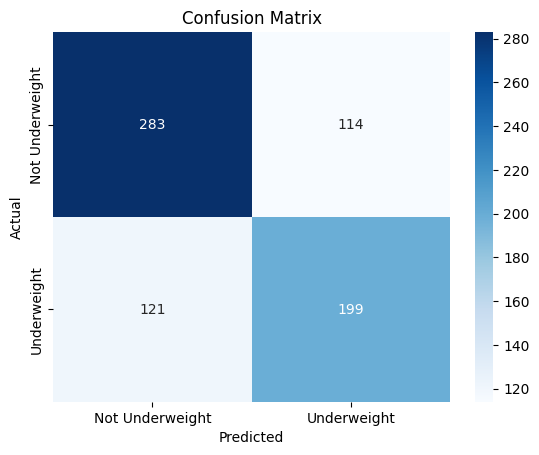

In [14]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Underweight', 'Underweight'], yticklabels=['Not Underweight', 'Underweight'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [15]:
# Use model.predict() and flatten to 1D
y_probas = model.predict(X_test).ravel()

# Compute Average Precision Score
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Average Precision: 0.6317340973472244


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


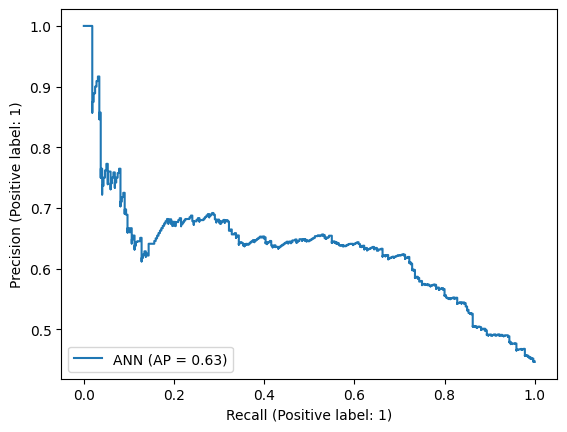

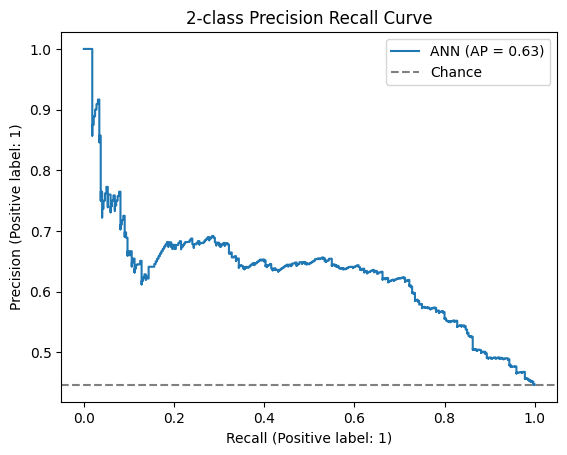

In [16]:
# Get predicted probabilities
y_probas = model.predict(X_test).ravel()

# Plot using from_predictions
display = PrecisionRecallDisplay.from_predictions(
    y_test,
    y_probas,
    name="ANN"
)
display.plot()
plt.axhline(y=sum(y_test) / len(y_test), color='gray', linestyle='--', label='Chance')
plt.title('2-class Precision Recall Curve')
plt.legend()
plt.show()
